In [1]:
!pip install langgraph langchain langchain_community langchain_huggingface

In [2]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage

In [5]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
# from google.colab import userdata
# userdata.get('HUGGINGFACEHUB_API_TOKEN')

In [10]:
# import os
# os.environ["HUGGINGFACEHUB_API_TOKEN"] =

In [12]:
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
model = ChatHuggingFace(llm = llm)

In [18]:
def chat(state: ChatState):
  messages = state['messages']
  response = model.invoke(messages)
  return {'messages': [response]}

In [19]:
graph = StateGraph(ChatState)
graph.add_node('chat', chat)

graph.add_edge(START, 'chat')
graph.add_edge('chat', END)

ChatWorkFlow = graph.compile()

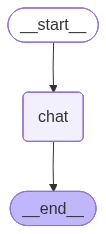

In [20]:
ChatWorkFlow

In [25]:
initialState = {
    'messages': [HumanMessage(content = 'What is the capital of India?')]
}
ChatWorkFlow.invoke(initialState)['messages'][-1].content

'The capital of India is New Delhi.'

In [33]:
chat_history = []

while True:
    user_message = input("Enter your query: ")

    if not user_message.strip():
        print("Please enter a valid question.\n")
        continue

    chat_history.append(HumanMessage(content=user_message))

    response = ChatWorkFlow.invoke({'messages': chat_history})

    ai_message = response['messages'][-1]

    print("\nAnswer:", ai_message.content)

    chat_history.append(ai_message)

    continue_chat = input("Do you want to ask another question? (yes/no): ").strip().lower()

    if continue_chat not in ['yes', 'y']:
        print("\nThank you. Goodbye!")
        break

Enter your query: Who is virat kohli>

Answer: Virat Kohli is one of the most prominent and successful cricketers in the history of the sport. He is an Indian cricketer who plays as a right-handed batsman and is known for his aggressive batting style, strong run-scoring ability, and leadership qualities.

### Key Highlights of Virat Kohli:

- **Full Name**: Virat Kohli  
- **Date of Birth**: November 5, 1988  
- **Place of Birth**: Delhi, India  
- **Nationality**: Indian  
- **Role**: Batsman (Top-order, aggressive)  
- **Teams**:  
  - India (International Cricket Team)  
  - Royal Challengers Bangalore (IPL)  
  - India A, India Under-19s, etc.

### Career Achievements:

1. **International Career**:
   - One of the highest run-scorers in Test, ODI, and T20I cricket.
   - **Test Cricket**: Over 7,000 runs with over 100 centuries (as of 2024).
   - **ODI Cricket**: Over 8,000 runs, with over 40 half-centuries and multiple centuries.
   - **T20I Cricket**: Over 2,000 runs with multiple

### Persistance in Langgraph

In [34]:
from langgraph.checkpoint.memory import MemorySaver

In [36]:
chechPointer = MemorySaver()
graph2 = StateGraph(ChatState)
graph2.add_node('chat', chat)

graph2.add_edge(START, 'chat')
graph2.add_edge('chat', END)

chatbot = graph2.compile(checkpointer= chechPointer)

In [39]:
thread_id = '1'

while True:
    user_message = input("Enter your query: ")

    if not user_message.strip():
        print("Please enter a valid question.\n")
        continue
    print("\nGenerating Response...\n")
    config = {'configurable': {'thread_id': thread_id}}

    response = chatbot.invoke({'messages': HumanMessage(content= user_message)}, config = config)

    ai_message = response['messages'][-1]

    print("\nResponse:", ai_message.content)

    continue_chat = input("Do you want to ask another question? (yes/no): ").strip().lower()

    if continue_chat not in ['yes', 'y']:
        print("\nThank you. Goodbye!")
        break

Enter your query: Who is Virat Kohli?

Generating Response...


Response: Virat Kohli is one of the most celebrated and influential cricketers in the world, renowned for his aggressive batting, consistency, and leadership. Born on **November 5, 1988**, in Delhi, India, Kohli is widely recognized as one of the greatest batsmen in the history of cricket.

### Key Highlights of Virat Kohli's Career:

🔹 **International Cricket**:
- **Test Cricket**: Kohli has scored over **10,000 runs** in Test matches, making him one of the top run-scorers in the format. He is known for his powerful stroke play, ability to score quickly, and resilience under pressure.
- **ODI Cricket**: He holds the record for the **most runs in ODI cricket** (as of 2024), surpassing legends like Sachin Tendulkar. He is also among the leading run-scorers in ODI history.
- **T20 Cricket**: Kohli led India to victory in the **2021 ICC T20 World Cup**, showcasing his leadership and explosive batting. He is one of the highest

In [40]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Who is virat kohli?', additional_kwargs={}, response_metadata={}, id='c971198a-8f34-4e4a-b16d-43032e5a7914'), AIMessage(content="Virat Kohli is an Indian cricketer widely regarded as one of the greatest batsmen in the history of the sport. Born on November 5, 1988, in Delhi, India, Kohli is known for his aggressive batting style, exceptional run-scoring ability, and leadership qualities.\n\nKey highlights of Virat Kohli's career:\n\n- **International Career**: He played for India in all formats of the game—Test, One Day Internationals (ODIs), and Twenty20 Internationals (T20Is). He made his Test debut in 2008 and his ODI debut in 2008 as well.\n\n- **T20 Leadership**: Kohli captained India in T20Is from 2014 to 2019 and was a key figure in India’s rise as a dominant force in T20 cricket. He led India to win the ICC T20 World Cup in 2021.\n\n- **ODI Record Holder**: Kohli holds the record for the most runs scored in ODIs (as of 20